# 03 Finalise Labels and Build the Modelling Dataset

本 Notebook 将第二步的 polarity 规则、P0/P1/P3 人工复核和 high-confidence QC 合并为最终标签，并生成第一版模型所需的文本、政治结构和政策主题特征。

核心原则：

1. 人工复核优先于自动规则；
2. Validation/Test 使用已经人工完成的 P0、P1 和 P3；
3. Train 暂时只使用 high-confidence 自动标签，未复核的 P2/P3 不进入第一版模型；
4. 主题分类仅使用投票前可获得的标题、正文和 legislation 名称；
5. TF-IDF 不在这里拟合，必须在建模 Notebook 中仅使用 Train 拟合。

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 140)

BASE_DIR = Path.cwd()
if not (BASE_DIR / 'processed').exists():
    BASE_DIR = BASE_DIR / 'reorganised'

PROCESSED_DIR = BASE_DIR / 'processed'
REVIEW_DIR = PROCESSED_DIR / 'polarity_review'
OUTPUT_DIR = PROCESSED_DIR / 'model_v2'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PARTY_PATH = PROCESSED_DIR / 'commons_party_motion_audit.csv'
DIVISION_PATH = REVIEW_DIR / 'division_annotation_base.csv'
REVIEW_PATH = REVIEW_DIR / 'evaluation_reviewed_all.csv'
QC_PATH = REVIEW_DIR / 'high_confidence_qc_manually_reviewed.csv'

print('Input directory:', PROCESSED_DIR.resolve())
print('Output directory:', OUTPUT_DIR.resolve())

Input directory: /Users/oooo1/01Course/2_70202Applying/reorganised/processed
Output directory: /Users/oooo1/01Course/2_70202Applying/reorganised/processed/model_v2


## 1. Load and validate the input tables

`commons_party_motion_audit.csv` 是四个政党的 party-level 数据；`division_annotation_base.csv` 是修正后的 division-level polarity 审计表；人工复核表只包含评测集记录。

In [2]:
party_rows = pd.read_csv(PARTY_PATH, parse_dates=['motion_date'])
divisions = pd.read_csv(DIVISION_PATH, parse_dates=['motion_date'])
reviews = pd.read_csv(REVIEW_PATH, dtype={'human_motion_polarity': 'string'})
high_qc = pd.read_csv(QC_PATH, dtype={'human_motion_polarity': 'string'})

assert len(party_rows) == 8364
assert party_rows['division_key'].nunique() == 2091
assert len(divisions) == 2091
assert divisions['division_key'].is_unique
assert len(reviews) == 263
assert reviews['division_key'].is_unique
assert set(party_rows['party']) == {'conservative', 'green', 'labour', 'liberal-democrat'}

print('Party-level rows:', len(party_rows))
print('Divisions:', len(divisions))
print('Reviewed evaluation divisions:', len(reviews))
display(pd.crosstab(reviews['review_priority'], reviews['split']))

Party-level rows: 8364
Divisions: 2091
Reviewed evaluation divisions: 263


split,test,validation
review_priority,,
P0,115,0
P1,0,54
P3,56,38


## 2. Freeze final division-level labels

自动标签只有在 `polarity_confidence = high` 时进入第一版数据。人工复核的 `1/-1` 覆盖自动规则；人工 `exclude`、高置信度 QC 中的 source issue 和 multi-policy 记录不进入模型。

In [3]:
division_labels = divisions.copy()

# 先初始化最终审计字段，避免旧标签自动流入模型。
division_labels['final_motion_polarity'] = pd.Series(pd.NA, index=division_labels.index, dtype='Int64')
division_labels['final_polarity_source'] = 'excluded'
division_labels['final_polarity_confidence'] = 'not_usable'
division_labels['final_exclusion_reason'] = pd.NA
division_labels['manual_reviewed'] = False
division_labels['final_policy_object'] = pd.NA
division_labels['final_aye_action'] = pd.NA

# 第一版训练数据只接受 high-confidence 自动 polarity。
rule_mask = (
    division_labels['eligible_for_stance_model'].fillna(False)
    & division_labels['polarity_confidence'].eq('high')
    & division_labels['motion_polarity'].notna()
)
division_labels.loc[rule_mask, 'final_motion_polarity'] = (
    division_labels.loc[rule_mask, 'motion_polarity'].astype('Int64')
)
division_labels.loc[rule_mask, 'final_polarity_source'] = 'rule_high'
division_labels.loc[rule_mask, 'final_polarity_confidence'] = 'high'

# 把人工复核字段按 division_key 合并；人工结果具有最高优先级。
review_fields = reviews[[
    'division_key', 'human_motion_polarity', 'human_object_government_backed',
    'policy_object', 'aye_action', 'review_status', 'review_notes'
]].copy()
review_fields = review_fields.rename(columns={
    'review_status': 'manual_review_status',
    'review_notes': 'manual_review_notes',
})
division_labels = division_labels.merge(review_fields, on='division_key', how='left', validate='one_to_one')

manual_mask = division_labels['manual_review_status'].eq('approved')
manual_numeric = pd.to_numeric(division_labels['human_motion_polarity'], errors='coerce').astype('Int64')
manual_include = manual_mask & manual_numeric.isin([-1, 1])
manual_exclude = manual_mask & division_labels['human_motion_polarity'].eq('exclude')

division_labels.loc[manual_include, 'final_motion_polarity'] = manual_numeric[manual_include]
division_labels.loc[manual_include, 'final_polarity_source'] = 'human_review'
division_labels.loc[manual_include, 'final_polarity_confidence'] = 'human_validated'
division_labels.loc[manual_include, 'final_exclusion_reason'] = pd.NA

division_labels.loc[manual_exclude, 'final_motion_polarity'] = pd.NA
division_labels.loc[manual_exclude, 'final_polarity_source'] = 'human_exclude'
division_labels.loc[manual_exclude, 'final_polarity_confidence'] = 'human_validated'
division_labels.loc[manual_exclude, 'final_exclusion_reason'] = division_labels.loc[manual_exclude, 'manual_review_notes']

division_labels.loc[manual_mask, 'manual_reviewed'] = True
division_labels.loc[manual_mask, 'final_policy_object'] = division_labels.loc[manual_mask, 'policy_object']
division_labels.loc[manual_mask, 'final_aye_action'] = division_labels.loc[manual_mask, 'aye_action']

# 高置信度 QC 中的多政策和源数据错误记录明确排除。
qc_status = high_qc.set_index('division_key')['review_status']
division_labels['high_qc_status'] = division_labels['division_key'].map(qc_status)
qc_exclude = division_labels['high_qc_status'].isin(['needs_source_fix', 'exclude_or_split_multi_policy'])
division_labels.loc[qc_exclude, 'final_motion_polarity'] = pd.NA
division_labels.loc[qc_exclude, 'final_polarity_source'] = 'high_qc_exclude'
division_labels.loc[qc_exclude, 'final_polarity_confidence'] = 'human_validated'
division_labels.loc[
    division_labels['high_qc_status'].eq('needs_source_fix'), 'final_exclusion_reason'
] = 'High-confidence QC found inconsistent or missing source text.'
division_labels.loc[
    division_labels['high_qc_status'].eq('exclude_or_split_multi_policy'), 'final_exclusion_reason'
] = 'High-confidence QC found multiple policy objects.'

# 为所有未纳入模型的 division 保留可审计的排除原因。
remaining = division_labels['final_motion_polarity'].isna() & division_labels['final_exclusion_reason'].isna()
division_labels.loc[
    remaining & division_labels['procedural_exclusion_reason'].notna(), 'final_exclusion_reason'
] = division_labels.loc[
    remaining & division_labels['procedural_exclusion_reason'].notna(), 'procedural_exclusion_reason'
]
division_labels.loc[
    remaining & division_labels['polarity_confidence'].eq('medium'), 'final_exclusion_reason'
] = 'Unreviewed medium-confidence training label.'
division_labels.loc[
    remaining & division_labels['polarity_confidence'].eq('unknown'), 'final_exclusion_reason'
] = 'Unreviewed unknown training label.'
division_labels['final_exclusion_reason'] = division_labels['final_exclusion_reason'].fillna('Not eligible for the first modelling dataset.')

division_labels['final_label_eligible'] = division_labels['final_motion_polarity'].isin([-1, 1])

# 政府背书只使用人工证据或 high-confidence 建议，缺失保持 unknown。
division_labels['final_object_government_backed'] = pd.Series(pd.NA, index=division_labels.index, dtype='Int64')
division_labels['final_government_backing_source'] = 'unknown'
backing_rule_mask = (
    division_labels['suggested_government_backing_confidence'].eq('high')
    & division_labels['suggested_object_government_backed'].notna()
)
division_labels.loc[backing_rule_mask, 'final_object_government_backed'] = (
    division_labels.loc[backing_rule_mask, 'suggested_object_government_backed'].astype('Int64')
)
division_labels.loc[backing_rule_mask, 'final_government_backing_source'] = 'rule_high'

manual_backing = pd.to_numeric(division_labels['human_object_government_backed'], errors='coerce').astype('Int64')
manual_backing_mask = manual_mask & manual_backing.isin([0, 1])
division_labels.loc[manual_backing_mask, 'final_object_government_backed'] = manual_backing[manual_backing_mask]
division_labels.loc[manual_backing_mask, 'final_government_backing_source'] = 'human_review'
division_labels['government_backing_known'] = division_labels['final_object_government_backed'].notna().astype('int8')

assert division_labels['division_key'].is_unique
assert division_labels.loc[manual_exclude, 'final_motion_polarity'].isna().all()
assert not division_labels.loc[qc_exclude, 'final_label_eligible'].any()

display(pd.crosstab(
    [division_labels['split'], division_labels['final_polarity_source']],
    division_labels['final_label_eligible'],
).rename(columns={False: 'excluded', True: 'included'}))

final_label_eligible              excluded  included
split      final_polarity_source                    
test       excluded                     11         0
           human_exclude                73         0
           human_review                  0        98
           rule_high                     0       256
train      excluded                    680         0
           high_qc_exclude               3         0
           rule_high                     0       770
validation excluded                      8         0
           human_exclude                23         0
           human_review                  0        69
           rule_high                     0       100

## 3. Join final labels back to party-level rows

这里删除第一步的旧 polarity 和旧 target，再从冻结后的 division 表重新计算，避免旧结果残留。

In [4]:
old_annotation_columns = [
    'motion_polarity', 'polarity_rule', 'polarity_confidence',
    'object_government_backed', 'government_backing_rule', 'government_backing_confidence',
    'target_policy_stance_score', 'target_policy_result', 'target_policy_stance',
    'target_binary_support', 'target_ordinal_provisional',
]
party_base = party_rows.drop(columns=[c for c in old_annotation_columns if c in party_rows.columns])

division_join_columns = [
    'division_key', 'matched_bill_id', 'matched_bill_title', 'bill_link_method',
    'bill_link_confidence', 'bill_sponsor_parties', 'bill_sponsor_organisations',
    'bill_government_organisations', 'final_motion_polarity', 'final_polarity_source',
    'final_polarity_confidence', 'final_label_eligible', 'final_exclusion_reason',
    'manual_reviewed', 'final_policy_object', 'final_aye_action',
    'final_object_government_backed', 'final_government_backing_source',
    'government_backing_known',
]
party_features = party_base.merge(
    division_labels[division_join_columns],
    on='division_key',
    how='left',
    validate='many_to_one',
)

assert len(party_features) == len(party_rows)
assert party_features['row_id'].is_unique
assert party_features['final_label_eligible'].notna().all()
print('Joined party rows:', len(party_features))

Joined party rows: 8364


## 4. Text, institutional and structural features

这些字段都能在投票前获得。`party_object_alignment` 表示政党角色与被表决对象政府背书之间的结构关系，不使用实际投票结果。

In [5]:
text_columns = [
    'division_name_clean', 'motion_title_clean', 'motion_text_clean',
    'legislation_name_clean',
]
for column in text_columns:
    party_features[column] = party_features[column].fillna('').astype(str)

party_features['model_text'] = (
    '[DIVISION] ' + party_features['division_name_clean']
    + ' [TITLE] ' + party_features['motion_title_clean']
    + ' [MOTION] ' + party_features['motion_text_clean']
    + ' [LEGISLATION] ' + party_features['legislation_name_clean']
).str.replace(r'\s+', ' ', regex=True).str.strip()

party_features['model_text_char_count'] = party_features['model_text'].str.len().astype('int32')
party_features['model_text_word_count'] = party_features['model_text'].str.split().str.len().astype('int32')
party_features['has_legislation_name'] = party_features['legislation_name_clean'].ne('').astype('int8')
party_features['bill_link_available'] = party_features['matched_bill_id'].notna().astype('int8')
party_features['is_governing_party'] = party_features['party_role'].eq('governing_party').astype('int8')
party_features['is_main_opposition'] = party_features['party_role'].eq('main_opposition').astype('int8')
party_features['years_since_2016'] = (party_features['motion_year'] - 2016).astype('int16')

combined_lower = (
    party_features['division_name_clean'].fillna('') + ' '
    + party_features['motion_title_clean'] + ' '
    + party_features['motion_text_clean']
).str.lower()

party_features['is_opposition_day'] = combined_lower.str.contains('opposition day', regex=False).astype('int8')
party_features['is_amendment'] = party_features['motion_type'].isin([
    'amendment', 'lords_amendment', 'reasoned_amendment', 'proposed_clause',
    'add_clause_to_bill', 'committee_clause',
]).astype('int8')
party_features['is_new_clause'] = combined_lower.str.contains(r'\bnew clause\b', regex=True).astype('int8')
party_features['is_financial_motion'] = party_features['motion_type'].isin(['financial']).astype('int8')

def motion_family(motion_type):
    if motion_type in {'amendment', 'lords_amendment', 'reasoned_amendment', 'proposed_clause', 'add_clause_to_bill', 'committee_clause'}:
        return 'amendment_or_clause'
    if motion_type in {'bill_introduction', 'second_stage', 'third_stage'}:
        return 'bill_stage'
    if motion_type in {'approve_statutory_instrument', 'revoke_statutory_instrument', 'eu_document_scrutiny'}:
        return 'delegated_legislation'
    if motion_type in {'financial'}:
        return 'finance'
    if motion_type in {'adjournment', 'closure', 'programme', 'timetable_change', 'private_sitting', 'reasons_committee'}:
        return 'procedural'
    return 'other_motion'

party_features['motion_family'] = party_features['motion_type'].map(motion_family)

party_features['party_object_alignment'] = 'unknown'
known_backing = party_features['final_object_government_backed'].notna()
expected_aligned = known_backing & (
    (
        party_features['final_object_government_backed'].eq(1)
        & party_features['party_role'].eq('governing_party')
    )
    | (
        party_features['final_object_government_backed'].eq(0)
        & party_features['party_role'].ne('governing_party')
    )
)
party_features.loc[known_backing, 'party_object_alignment'] = 'structurally_opposed'
party_features.loc[expected_aligned, 'party_object_alignment'] = 'structurally_aligned'

display(party_features[[
    'division_key', 'party', 'party_role', 'final_object_government_backed',
    'party_object_alignment', 'motion_family', 'model_text'
]].head(8))

,division_key,party,party_role,final_object_government_backed,party_object_alignment,motion_family,model_text
0,pw-2016-01-06-157-commons,conservative,governing_party,<NA>,unknown,other_motion,[DIVISION] Opposition Day — Universal Credit Work Allowance — Decision to Cut [TITLE] Opposition Day — [14th Allotted Day] — Universal C...
1,pw-2016-01-06-157-commons,green,smaller_opposition,<NA>,unknown,other_motion,[DIVISION] Opposition Day — Universal Credit Work Allowance — Decision to Cut [TITLE] Opposition Day — [14th Allotted Day] — Universal C...
2,pw-2016-01-06-157-commons,labour,main_opposition,<NA>,unknown,other_motion,[DIVISION] Opposition Day — Universal Credit Work Allowance — Decision to Cut [TITLE] Opposition Day — [14th Allotted Day] — Universal C...
3,pw-2016-01-06-157-commons,liberal-democrat,smaller_opposition,<NA>,unknown,other_motion,[DIVISION] Opposition Day — Universal Credit Work Allowance — Decision to Cut [TITLE] Opposition Day — [14th Allotted Day] — Universal C...
4,pw-2016-01-06-158-commons,conservative,governing_party,<NA>,unknown,other_motion,[DIVISION] Opposition Day — [14th Allotted Day] — Universal Credit Work Allowance — Flooding [TITLE] Opposition Day — [14th Allotted Day...
5,pw-2016-01-06-158-commons,green,smaller_opposition,<NA>,unknown,other_motion,[DIVISION] Opposition Day — [14th Allotted Day] — Universal Credit Work Allowance — Flooding [TITLE] Opposition Day — [14th Allotted Day...
6,pw-2016-01-06-158-commons,labour,main_opposition,<NA>,unknown,other_motion,[DIVISION] Opposition Day — [14th Allotted Day] — Universal Credit Work Allowance — Flooding [TITLE] Opposition Day — [14th Allotted Day...
7,pw-2016-01-06-158-commons,liberal-democrat,smaller_opposition,<NA>,unknown,other_motion,[DIVISION] Opposition Day — [14th Allotted Day] — Universal Credit Work Allowance — Flooding [TITLE] Opposition Day — [14th Allotted Day...


## 5. Policy-domain features

为保持与原论文可比，先复现五个 legacy flags：Economy & Finance、Justice & Security、Environment & Infrastructure、Social Benefits & Health、National Affairs。

由于原分类把 Education、Health 和 Welfare 合并得过粗，本版本另外生成 V2 多标签主题和一个 primary domain。V2 主题只作为结构化特征和分析维度；TF-IDF 仍直接使用全文。

In [6]:
legacy_domain_rules = {
    'is_econ_finance': [
        'finance', 'budget', 'tax', 'duty', 'economic', 'economy', 'business',
        'trade', 'export', 'import', 'insurance', 'bank', 'investment', 'fiscal',
        'stamp duty', 'national insurance', 'corporation tax',
    ],
    'is_justice_security': [
        'police', 'sentencing', 'crime', 'criminal', 'justice', 'security',
        'intelligence', 'border', 'asylum', 'immigration', 'prison', 'court',
        'victim', 'terrorism', 'fraud',
    ],
    'is_env_infra': [
        'energy', 'climate', 'environment', 'water', 'pollution', 'housing',
        'planning', 'rail', 'railway', 'transport', 'road', 'bus', 'electricity',
        'nuclear', 'infrastructure',
    ],
    'is_social_health': [
        'health', 'care', 'nhs', 'education', 'school', 'child', 'family',
        'benefit', 'welfare', 'poverty', 'tobacco', 'vape', 'social housing',
        'pension', 'disability',
    ],
    'is_national_affairs': [
        'scotland', 'wales', 'northern ireland', 'european union', 'brexit',
        'referendum', 'house of lords', 'parliament', 'election', 'constitution',
        'devolution', 'sovereignty',
    ],
}

v2_domain_rules = {
    'economy_finance_business': [
        'finance', 'budget', 'tax', 'duty', 'economic', 'economy', 'business',
        'trade', 'export', 'import', 'bank', 'investment', 'fiscal', 'rating',
    ],
    'employment_labour': [
        'employment', 'employer', 'employee', 'worker', 'workplace', 'trade union',
        'industrial action', 'wage', 'pay and conditions',
    ],
    'welfare_pensions_poverty': [
        'universal credit', 'benefit', 'welfare', 'poverty', 'pension',
        'personal independence payment', 'carer allowance', 'social security',
    ],
    'health_social_care': [
        'health', 'nhs', 'hospital', 'mental health', 'social care', 'tobacco',
        'vape', 'assisted dying', 'abortion', 'medical',
    ],
    'education_skills_children': [
        'education', 'school', 'student', 'university', 'apprentice', 'skills',
        'child', 'children', 'pupil', 'special educational needs',
    ],
    'justice_crime_policing': [
        'police', 'sentencing', 'crime', 'criminal', 'justice', 'prison', 'court',
        'victim', 'fraud', 'offence', 'weapon',
    ],
    'immigration_asylum': [
        'immigration', 'asylum', 'refugee', 'border security', 'visa', 'rwanda',
    ],
    'housing_planning_local_government': [
        'housing', 'rent', 'landlord', 'tenant', 'planning', 'local authority',
        'local government', 'devolution', 'council', 'leasehold',
    ],
    'transport_infrastructure': [
        'rail', 'railway', 'transport', 'road', 'bus', 'vehicle', 'airport',
        'infrastructure', 'high speed rail',
    ],
    'environment_energy_water': [
        'climate', 'environment', 'water', 'pollution', 'energy', 'electricity',
        'nuclear', 'renewable', 'nature', 'biodiversity', 'net zero',
    ],
    'defence_foreign_affairs': [
        'defence', 'armed forces', 'military', 'foreign affairs', 'treaty',
        'ukraine', 'mauritius', 'diego garcia', 'international',
    ],
    'constitution_democracy_devolution': [
        'parliament', 'house of lords', 'election', 'referendum', 'constitution',
        'scotland', 'wales', 'northern ireland', 'sovereignty', 'democratic',
    ],
    'digital_data_media_ai': [
        'data', 'digital', 'artificial intelligence', ' ai ', 'online safety',
        'copyright', 'media', 'broadcast', 'internet', 'technology',
    ],
    'agriculture_food_rural': [
        'agriculture', 'agricultural', 'farmer', 'farming', 'food', 'rural',
        'fisheries', 'animal',
    ],
    'culture_sport': [
        'sport', 'football', 'olympic', 'music', 'culture', 'heritage',
        'broadcasting rights',
    ],
}

def term_score(text, terms):
    score = 0
    for term in terms:
        pattern = r'(?<!\w)' + re.escape(term.strip()) + r'(?!\w)'
        score += int(bool(re.search(pattern, text)))
    return score

domain_text = party_features['model_text'].str.lower()
for column, terms in legacy_domain_rules.items():
    party_features[column] = domain_text.map(lambda text: int(term_score(text, terms) > 0)).astype('int8')

party_features['legacy_domain_count'] = party_features[list(legacy_domain_rules)].sum(axis=1).astype('int8')

v2_score_columns = []
for domain, terms in v2_domain_rules.items():
    column = f'domain_score__{domain}'
    party_features[column] = domain_text.map(lambda text: term_score(text, terms)).astype('int8')
    v2_score_columns.append(column)

score_frame = party_features[v2_score_columns]
score_frame.columns = [column.replace('domain_score__', '') for column in score_frame.columns]
party_features['policy_domain_primary'] = score_frame.idxmax(axis=1)
no_domain = score_frame.max(axis=1).eq(0)
party_features.loc[no_domain, 'policy_domain_primary'] = 'other_or_unclear'

party_features['policy_domain_labels'] = score_frame.apply(
    lambda row: '|'.join(row.index[row.gt(0)]) if row.gt(0).any() else 'other_or_unclear',
    axis=1,
)
party_features['policy_domain_count'] = score_frame.gt(0).sum(axis=1).astype('int8')

sorted_scores = np.sort(score_frame.to_numpy(), axis=1)
top_score = sorted_scores[:, -1]
second_score = sorted_scores[:, -2]
party_features['policy_domain_confidence'] = np.select(
    [(top_score >= 2) & (top_score > second_score), top_score >= 1],
    ['high', 'medium'],
    default='low',
)
party_features['policy_domain_rule'] = 'keyword_multilabel_v2'

domain_summary = (
    party_features.drop_duplicates('division_key')['policy_domain_primary']
    .value_counts()
    .rename_axis('policy_domain_primary')
    .to_frame('divisions')
)
display(domain_summary)

,divisions
policy_domain_primary,
economy_finance_business,516
other_or_unclear,406
constitution_democracy_devolution,183
justice_crime_policing,173
health_social_care,124
housing_planning_local_government,111
environment_energy_water,93
immigration_asylum,92
education_skills_children,90


## 6. Recalculate normalised targets

`raw_vote_score` 是历史投票产生的标签信息，只用于构造 target。它不会进入模型特征列表。

In [7]:
party_features['target_policy_stance_score'] = (
    party_features['raw_vote_score'].astype('Float64')
    * party_features['final_motion_polarity'].astype('Float64')
)
party_features['target_policy_result'] = party_features['target_policy_stance_score'].map(
    lambda value: pd.NA if pd.isna(value) else int(np.sign(value))
).astype('Int64')
party_features['target_policy_stance'] = party_features['target_policy_result'].map({
    -1: 'oppose', 0: 'mixed_or_neutral', 1: 'support',
}).astype('string')
party_features['target_binary_support'] = party_features['target_policy_result'].map({
    -1: 0, 1: 1,
}).astype('Int64')

ordinal_labels = ['strongly_oppose', 'oppose', 'mixed_or_neutral', 'support', 'strongly_support']
party_features['target_ordinal_provisional'] = pd.cut(
    party_features['target_policy_stance_score'].astype(float),
    bins=[-np.inf, -0.60, -0.20, 0.20, 0.60, np.inf],
    labels=ordinal_labels,
    include_lowest=True,
    right=False,
).astype('string')

target_check_mask = (
    party_features['final_label_eligible']
    & party_features['raw_vote_score'].notna()
)
expected_result = np.sign(
    party_features.loc[target_check_mask, 'raw_vote_score']
    * party_features.loc[target_check_mask, 'final_motion_polarity']
).astype('int64')
actual_result = party_features.loc[target_check_mask, 'target_policy_result'].astype('int64')
assert np.array_equal(expected_result.to_numpy(), actual_result.to_numpy())

display(pd.crosstab(
    party_features['split'],
    party_features['target_policy_stance'],
    margins=True,
))

target_policy_stance,mixed_or_neutral,oppose,support,All
split,,,,
test,4,544,745,1293
train,2,1216,1606,2824
validation,2,233,337,572
All,8,1993,2688,4689


## 7. Build leakage-safe modelling files

第一版主任务为 binary support/oppose。因此 mixed/tied party rows 暂不进入模型；它们仍保留在 division 和完整审计数据中。

In [8]:
audit_columns = [
    'row_id', 'division_key', 'motion_date', 'split', 'party',
    'final_motion_polarity', 'final_polarity_source', 'final_polarity_confidence',
    'final_object_government_backed', 'final_government_backing_source',
    'government_backing_known', 'final_policy_object', 'final_aye_action',
]

text_feature_columns = [
    'model_text', 'division_name_clean', 'motion_title_clean',
    'motion_text_clean', 'legislation_name_clean',
]

categorical_feature_columns = [
    'party', 'party_role', 'government_party', 'main_opposition_party',
    'party_object_alignment', 'motion_type', 'motion_family',
    'policy_domain_primary', 'policy_domain_labels', 'policy_domain_confidence',
]

numeric_feature_columns = [
    'motion_year', 'motion_month', 'years_since_2016',
    'motion_char_count', 'motion_word_count', 'model_text_char_count', 'model_text_word_count',
    'total_possible_members', 'has_legislation_name', 'bill_link_available',
    'is_governing_party', 'is_main_opposition', 'is_opposition_day',
    'is_amendment', 'is_new_clause', 'is_financial_motion',
    'government_backing_known', 'final_object_government_backed',
    'legacy_domain_count', 'policy_domain_count',
    *legacy_domain_rules.keys(),
]

target_columns = [
    'target_policy_result', 'target_policy_stance', 'target_binary_support',
    'target_policy_stance_score', 'target_ordinal_provisional',
]

model_columns = list(dict.fromkeys(
    audit_columns + text_feature_columns + categorical_feature_columns
    + numeric_feature_columns + target_columns
))

# 只保留最终 polarity 可用且二分类 target 明确的 party rows。
model_ready = party_features.loc[
    party_features['final_label_eligible']
    & party_features['target_binary_support'].notna(),
    model_columns,
].copy()

model_train = model_ready.loc[model_ready['split'].eq('train')].copy()
model_validation = model_ready.loc[model_ready['split'].eq('validation')].copy()
model_test = model_ready.loc[model_ready['split'].eq('test')].copy()

assert model_ready['row_id'].is_unique
assert not model_ready['party'].eq('reform').any()
assert set(model_train['party']) == set(model_validation['party']) == set(model_test['party'])
assert model_train['final_polarity_source'].eq('rule_high').all()
assert not set(model_train['division_key']) & set(model_validation['division_key'])
assert not set(model_train['division_key']) & set(model_test['division_key'])
assert not set(model_validation['division_key']) & set(model_test['division_key'])

for frame in [model_train, model_validation, model_test]:
    assert set(frame['target_binary_support'].dropna().astype(int).unique()) == {0, 1}

summary_table = pd.DataFrame({
    'rows': [len(model_train), len(model_validation), len(model_test)],
    'divisions': [
        model_train['division_key'].nunique(),
        model_validation['division_key'].nunique(),
        model_test['division_key'].nunique(),
    ],
    'support_rate': [
        model_train['target_binary_support'].mean(),
        model_validation['target_binary_support'].mean(),
        model_test['target_binary_support'].mean(),
    ],
}, index=['train', 'validation', 'test'])
display(summary_table.round(3))

,rows,divisions,support_rate
train,2822,770,0.569
validation,570,169,0.591
test,1289,354,0.578


## 8. Feature registry

TF-IDF 会在下一步建模时对 `model_text` 拟合。主题分类和结构化字段将通过 ablation test 判断是否真正增加效果。

In [9]:
registry_rows = []
for field in text_feature_columns:
    registry_rows.append({
        'field': field, 'role': 'text_feature', 'available_at_inference': True,
        'notes': 'Pre-vote text. TF-IDF must be fitted on Train only.'
    })
for field in categorical_feature_columns:
    registry_rows.append({
        'field': field, 'role': 'categorical_feature', 'available_at_inference': True,
        'notes': 'Pre-vote categorical or rule-derived context.'
    })
for field in numeric_feature_columns:
    registry_rows.append({
        'field': field, 'role': 'numeric_feature', 'available_at_inference': True,
        'notes': 'Pre-vote numeric or binary context.'
    })
for field in target_columns:
    registry_rows.append({
        'field': field, 'role': 'target', 'available_at_inference': False,
        'notes': 'Historical vote outcome transformed by final motion polarity.'
    })
for field in ['row_id', 'division_key', 'split']:
    registry_rows.append({
        'field': field, 'role': 'identifier_or_split', 'available_at_inference': False,
        'notes': 'Used for grouping, audit and leakage-safe splitting.'
    })

feature_registry_v2 = pd.DataFrame(registry_rows).drop_duplicates('field')

for forbidden in [
    'party_result', 'party_for', 'party_against', 'party_for_percentage',
    'total_for', 'total_against', 'total_result', 'raw_vote_score',
]:
    assert forbidden not in text_feature_columns + categorical_feature_columns + numeric_feature_columns

display(feature_registry_v2)

,field,role,available_at_inference,notes
0,model_text,text_feature,True,Pre-vote text. TF-IDF must be fitted on Train only.
1,division_name_clean,text_feature,True,Pre-vote text. TF-IDF must be fitted on Train only.
2,motion_title_clean,text_feature,True,Pre-vote text. TF-IDF must be fitted on Train only.
3,motion_text_clean,text_feature,True,Pre-vote text. TF-IDF must be fitted on Train only.
4,legislation_name_clean,text_feature,True,Pre-vote text. TF-IDF must be fitted on Train only.
5,party,categorical_feature,True,Pre-vote categorical or rule-derived context.
6,party_role,categorical_feature,True,Pre-vote categorical or rule-derived context.
7,government_party,categorical_feature,True,Pre-vote categorical or rule-derived context.
8,main_opposition_party,categorical_feature,True,Pre-vote categorical or rule-derived context.
9,party_object_alignment,categorical_feature,True,Pre-vote categorical or rule-derived context.


## 9. Export the frozen V2 dataset

In [10]:
division_export_columns = [
    'division_key', 'motion_date', 'split', 'motion_type', 'motion_title_clean',
    'motion_text_clean', 'legislation_name_clean', 'final_motion_polarity',
    'final_polarity_source', 'final_polarity_confidence', 'final_label_eligible',
    'final_exclusion_reason', 'manual_reviewed', 'final_policy_object',
    'final_aye_action', 'final_object_government_backed',
    'final_government_backing_source', 'government_backing_known',
]

division_labels[division_export_columns].to_csv(
    OUTPUT_DIR / 'division_labels_final.csv', index=False
)
model_ready.to_csv(OUTPUT_DIR / 'model_ready_v2_all.csv', index=False)
model_train.to_csv(OUTPUT_DIR / 'model_train_v2.csv', index=False)
model_validation.to_csv(OUTPUT_DIR / 'model_validation_v2.csv', index=False)
model_test.to_csv(OUTPUT_DIR / 'model_test_v2.csv', index=False)
feature_registry_v2.to_csv(OUTPUT_DIR / 'feature_registry_v2.csv', index=False)

dataset_summary = {
    'division_rows_total': int(len(division_labels)),
    'division_rows_eligible': int(division_labels['final_label_eligible'].sum()),
    'party_rows_binary_model': int(len(model_ready)),
    'train_rows': int(len(model_train)),
    'validation_rows': int(len(model_validation)),
    'test_rows': int(len(model_test)),
    'train_divisions': int(model_train['division_key'].nunique()),
    'validation_divisions': int(model_validation['division_key'].nunique()),
    'test_divisions': int(model_test['division_key'].nunique()),
    'manual_evaluation_divisions': int(len(reviews)),
    'policy_domain_taxonomy': 'legacy_five_flags_plus_keyword_multilabel_v2',
    'tfidf_policy': 'fit_on_train_only_in_modelling_notebook',
}
with (OUTPUT_DIR / 'dataset_summary_v2.json').open('w', encoding='utf-8') as file:
    json.dump(dataset_summary, file, ensure_ascii=False, indent=2)

print('Exported files:')
for path in sorted(OUTPUT_DIR.iterdir()):
    print(' ', path.name)
display(pd.Series(dataset_summary, name='value').to_frame())

Exported files:
  dataset_summary_v2.json
  division_labels_final.csv
  feature_registry_v2.csv
  model_ready_v2_all.csv
  model_test_v2.csv
  model_train_v2.csv
  model_validation_v2.csv


,value
division_rows_total,2091
division_rows_eligible,1293
party_rows_binary_model,4681
train_rows,2822
validation_rows,570
test_rows,1289
train_divisions,770
validation_divisions,169
test_divisions,354
manual_evaluation_divisions,263


## 10. Topic distribution check

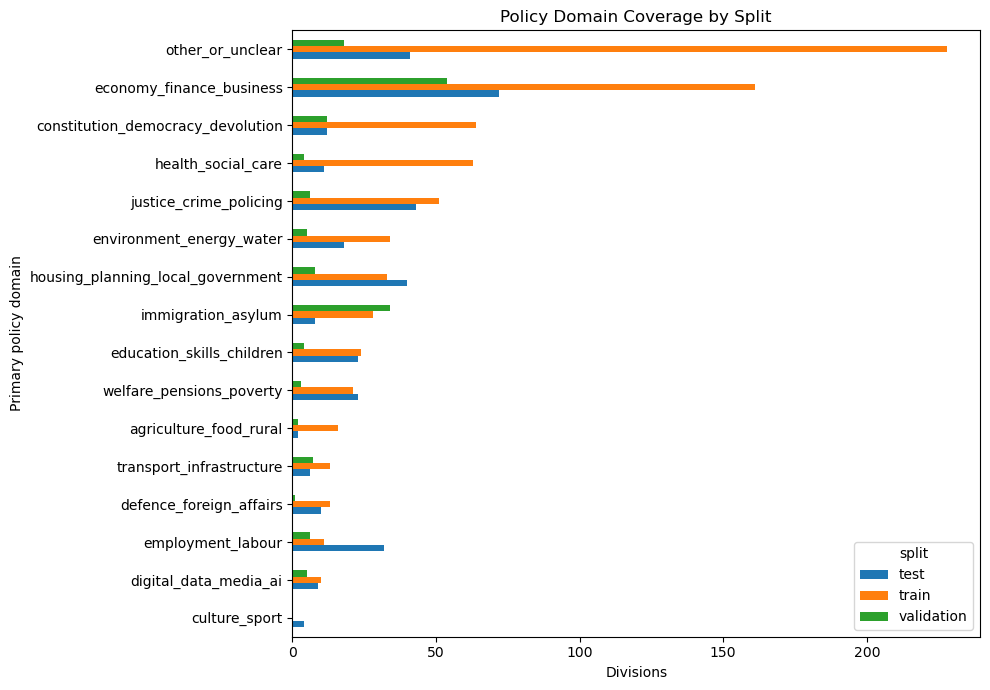

In [11]:
plot_data = (
    model_ready.drop_duplicates('division_key')
    .groupby(['policy_domain_primary', 'split'])
    .size()
    .unstack(fill_value=0)
    .sort_values('train', ascending=True)
)

ax = plot_data.plot(kind='barh', figsize=(10, 7))
ax.set_title('Policy Domain Coverage by Split')
ax.set_xlabel('Divisions')
ax.set_ylabel('Primary policy domain')
plt.tight_layout()
plt.show()

## Interpretation and limitations

- 旧论文的五个 policy flags 被保留，便于直接比较旧模型与新数据；
- V2 taxonomy 允许多标签，并将 Education、Employment、Welfare、Health 等拆开；
- 关键词主题可能误分，必须在下一步通过 ablation test 检查它是否真的提高 Validation/Test 表现；
- 主题特征不能替代 TF-IDF，因为 TF-IDF 能保留更细的措辞信号；
- `party_object_alignment` 是投票前结构信息，但政府背书未知时保持 `unknown`；
- P2 和 Train 中未复核的 P3 暂时排除，后续只有在训练样本不足或误差分析表明需要时才继续人工标注。